
# fix the intial loss
initially, the ouput should be equally, i.e. all characters should have
same probability as the next character, i.e. 1 / 27

which means the parametes (C, W1, b1, W2, b2) should be set in certain way so that
the logits / output layer's activation should all be equal, e.x. 0. 

since `logits = h @ W2 + b2`, we can set `b2 = 0` and `W2` to very small number, like 0.01

# fix the saturated tanh
intially the the hidden layer, after applying tanh, is saturated, i.e. quite some activation
of the hidden layer lays at near -1 or 1, which make them `dead neurons`. Because accoding to
the backward propagation rule, if `t` is near -1 or 1, the neuron will not learn anything:

`self.grad += (1 - t**2) * out.grad`

how to fix?

we do not want many saturated hidden neurons ->
we want the `hpreact` to be distributd in a smaller range around 0 ->
`hpreact = embcat @ W1 + b1` ->
let `b1 = 0` and set `W1` to small number



In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt     # for making figures
%matplotlib inline

In [21]:
# read all the words
words = open('../name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [22]:
len(words)

32033

In [23]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [24]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
# MLP revisited
n_emb = 10  # the demensionality of the character embedding vectors
n_hidden = 200  # the number of the neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)   # for reproducibility
C = torch.randn((vocab_size, n_emb),             generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                       generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),         generator=g) * 0.01
b2 = torch.randn(vocab_size,                     generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [40]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]   # batch X, Y

    # forward pass
    emb = C[Xb]     # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2    # output layer
    loss = F.cross_entropy(logits, Yb)  # loss functions

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01    # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break


      0/ 200000: 3.3135


(array([  1.,   2.,   0.,   1.,   5.,   3.,  11.,   6.,  13.,  10.,  25.,
         40.,  40.,  77.,  63., 101., 127., 171., 184., 220., 227., 267.,
        312., 301., 356., 367., 376., 360., 370., 331., 298., 278., 292.,
        242., 191., 167., 137., 104.,  85.,  77.,  41.,  30.,  28.,  20.,
         11.,   7.,  11.,   5.,   2.,   7.]),
 array([-3.76367116, -3.6200974 , -3.47652364, -3.33294988, -3.18937612,
        -3.04580235, -2.90222859, -2.75865483, -2.61508107, -2.47150731,
        -2.32793355, -2.18435979, -2.04078603, -1.89721227, -1.75363851,
        -1.61006474, -1.46649098, -1.32291722, -1.17934346, -1.0357697 ,
        -0.89219594, -0.74862218, -0.60504842, -0.46147466, -0.3179009 ,
        -0.17432714, -0.03075337,  0.11282039,  0.25639415,  0.39996791,
         0.54354167,  0.68711543,  0.83068919,  0.97426295,  1.11783671,
         1.26141047,  1.40498424,  1.548558  ,  1.69213176,  1.83570552,
         1.97927928,  2.12285304,  2.2664268 ,  2.41000056,  2.55357432,
 

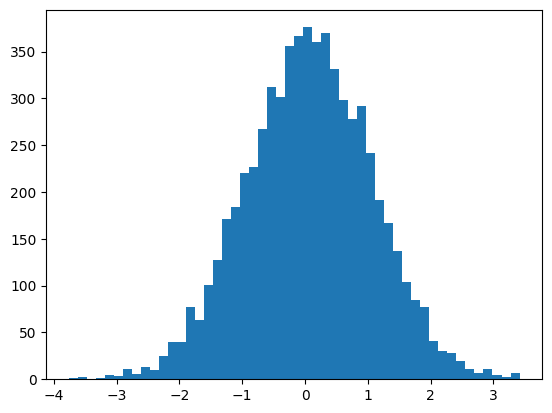

In [41]:
plt.hist(hpreact.view(-1).tolist(), 50)

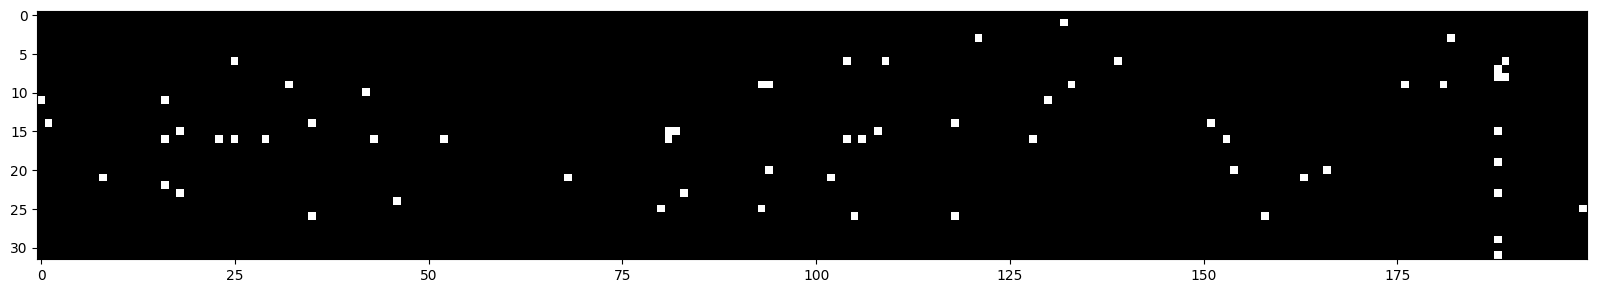

In [42]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

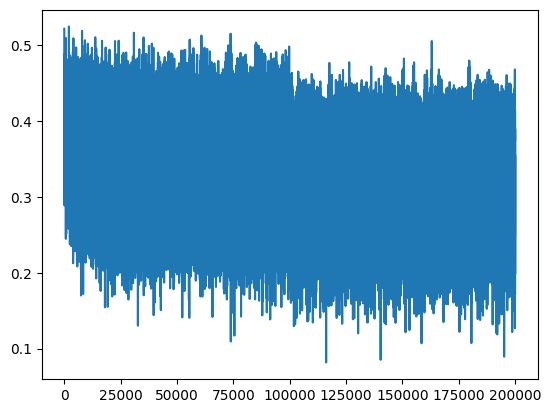

In [27]:
plt.plot(lossi)

In [28]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_emb)
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2    # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0695888996124268
val 2.131074905395508


In [29]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]    # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carman.
amille.
khyrmyn.
reet.
khalayane.
mahnen.
deliah.
jareei.
nellara.
chaiivon.
legen.
ham.
jorn.
quintin.
lilea.
jadiquinterri.
jarysia.
kael.
dustine.
deciia.
